# **Import Library**

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# **Load the Dataset**

In [9]:
df = pd.read_csv('global_house_purchase_dataset.csv')


In [10]:
df=df.drop(['property_id','garage','garden','customer_salary','monthly_expenses','connectivity_score','neighbourhood_rating','down_payment','loan_amount','crime_cases_reported','previous_owners','legal_cases_on_property'],axis=1)

In [11]:
df.head()

,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,rooms,bathrooms,loan_tenure_years,emi_to_income_ratio,satisfaction_score,decision
0,France,Marseille,Farmhouse,Semi-Furnished,991,412935,1989,6,2,15,0.16,1,0
1,South Africa,Cape Town,Apartment,Semi-Furnished,1244,224538,1990,8,8,20,0.08,9,0
2,South Africa,Johannesburg,Farmhouse,Semi-Furnished,4152,745104,2019,2,1,30,0.09,6,0
3,Germany,Frankfurt,Farmhouse,Semi-Furnished,3714,1110959,2008,3,3,15,0.33,2,0
4,South Africa,Johannesburg,Townhouse,Fully-Furnished,531,99041,2007,3,3,25,0.03,3,0


# **Understanding the Data**

In [12]:
df.info

<bound method DataFrame.info of              country            city property_type furnishing_status  \
0             France       Marseille     Farmhouse    Semi-Furnished   
1       South Africa       Cape Town     Apartment    Semi-Furnished   
2       South Africa    Johannesburg     Farmhouse    Semi-Furnished   
3            Germany       Frankfurt     Farmhouse    Semi-Furnished   
4       South Africa    Johannesburg     Townhouse   Fully-Furnished   
...              ...             ...           ...               ...   
199995       Germany          Berlin         Villa   Fully-Furnished   
199996         China        Shenzhen     Townhouse       Unfurnished   
199997         Japan           Kyoto         Villa    Semi-Furnished   
199998  South Africa    Johannesburg     Apartment       Unfurnished   
199999        Brazil  Rio de Janeiro     Apartment    Semi-Furnished   

        property_size_sqft    price  constructed_year  rooms  bathrooms  \
0                      991  

In [13]:
df.isnull().sum()

country                0
city                   0
property_type          0
furnishing_status      0
property_size_sqft     0
price                  0
constructed_year       0
rooms                  0
bathrooms              0
loan_tenure_years      0
emi_to_income_ratio    0
satisfaction_score     0
decision               0
dtype: int64

In [14]:
df.describe

<bound method NDFrame.describe of              country            city property_type furnishing_status  \
0             France       Marseille     Farmhouse    Semi-Furnished   
1       South Africa       Cape Town     Apartment    Semi-Furnished   
2       South Africa    Johannesburg     Farmhouse    Semi-Furnished   
3            Germany       Frankfurt     Farmhouse    Semi-Furnished   
4       South Africa    Johannesburg     Townhouse   Fully-Furnished   
...              ...             ...           ...               ...   
199995       Germany          Berlin         Villa   Fully-Furnished   
199996         China        Shenzhen     Townhouse       Unfurnished   
199997         Japan           Kyoto         Villa    Semi-Furnished   
199998  South Africa    Johannesburg     Apartment       Unfurnished   
199999        Brazil  Rio de Janeiro     Apartment    Semi-Furnished   

        property_size_sqft    price  constructed_year  rooms  bathrooms  \
0                      991

In [15]:
df.duplicated().sum()

0

In [16]:
df.shape

(200000, 13)

In [17]:
df['city'].value_counts()

city
Singapore         15278
São Paulo          7755
Johannesburg       7712
Cape Town          7689
Rio de Janeiro     7642
Dubai              7637
Abu Dhabi          7504
Marseille          5328
Beijing            5328
Melbourne          5289
Berlin             5241
Lyon               5220
Vancouver          5213
Shanghai           5209
Tokyo              5188
Sydney             5142
Frankfurt          5117
Montreal           5112
Paris              5080
Toronto            5076
Kyoto              5075
Osaka              5054
Munich             5050
Brisbane           5011
Shenzhen           4999
Birmingham         3935
London             3860
Liverpool          3825
Manchester         3793
Chicago            3107
San Francisco      3092
New York           3083
Los Angeles        3000
Houston            2999
Delhi              2583
Pune               2579
Bangalore          2579
Hyderabad          2571
Mumbai             2535
Chennai            2510
Name: count, dtype: int64

In [18]:
df['country'].value_counts()

country
France          15628
China           15536
Australia       15442
UK              15413
Germany         15408
South Africa    15401
Canada          15401
Brazil          15397
India           15357
Japan           15317
USA             15281
Singapore       15278
UAE             15141
Name: count, dtype: int64

In [19]:
df['property_type'].value_counts()

property_type
Farmhouse            33518
Apartment            33398
Townhouse            33395
Villa                33347
Independent House    33334
Studio               33008
Name: count, dtype: int64

In [20]:
df['furnishing_status'].value_counts()

furnishing_status
Fully-Furnished    66829
Semi-Furnished     66673
Unfurnished        66498
Name: count, dtype: int64

# **EDA**

<Axes: xlabel='property_type', ylabel='count'>

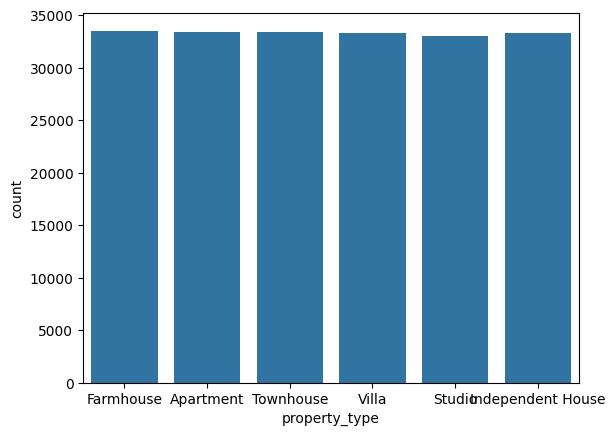

In [21]:
sns.countplot(x='property_type',data=df)

<Axes: xlabel='furnishing_status'>

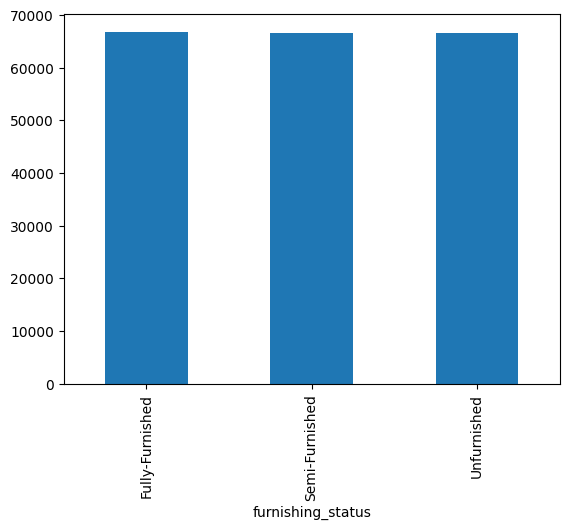

In [22]:
df['furnishing_status'].value_counts().plot(kind = 'bar')

<Axes: >

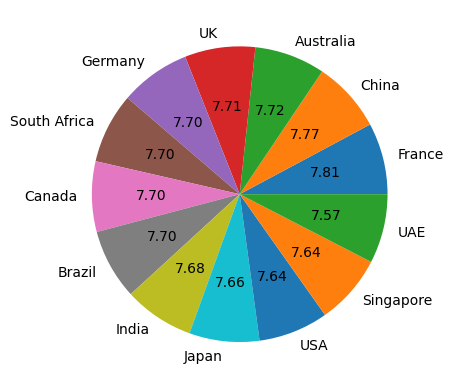

In [23]:
df['country'].value_counts().plot(kind = 'pie',autopct= '%.2f')

<Axes: >

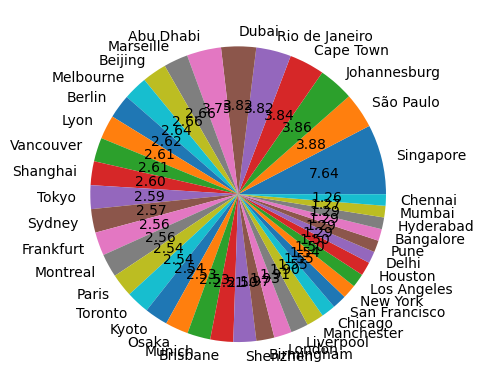

In [24]:
df['city'].value_counts().plot(kind = 'pie',autopct= '%.2f')

<Axes: xlabel='rooms', ylabel='bathrooms'>

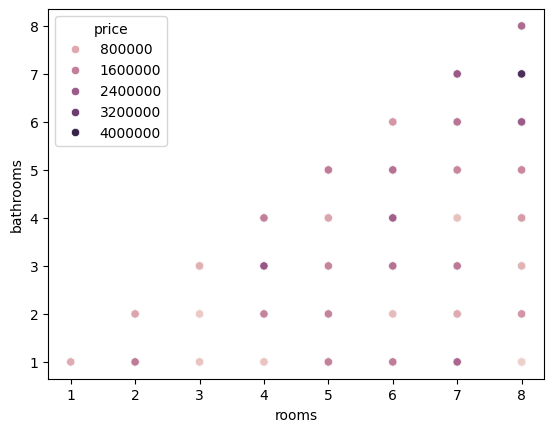

In [25]:
sns.scatterplot(x="rooms",y="bathrooms",hue="price",data= df )

<Axes: xlabel='rooms'>

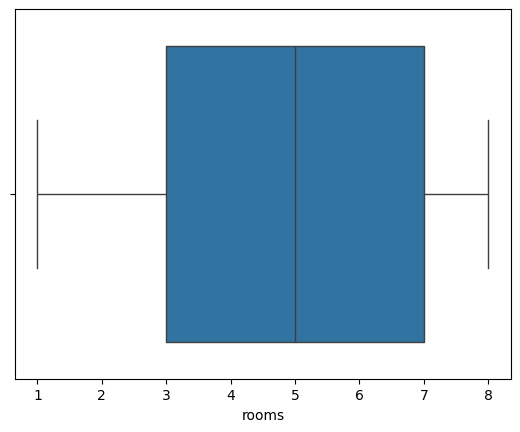

In [26]:
sns.boxplot(x='rooms',data=df)

<Axes: xlabel='rooms', ylabel='country'>

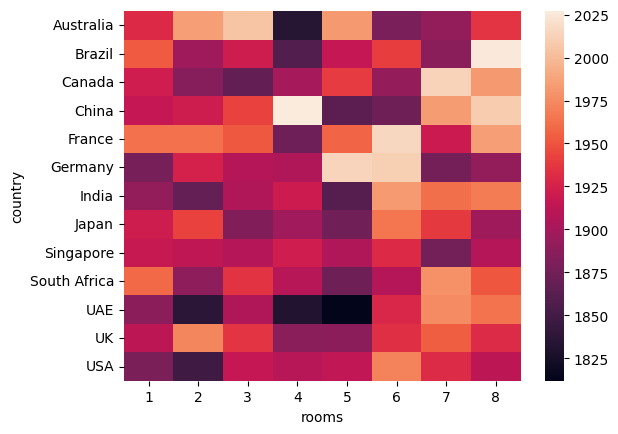

In [27]:
sns.heatmap(pd.crosstab(df["country"],df["rooms"]))

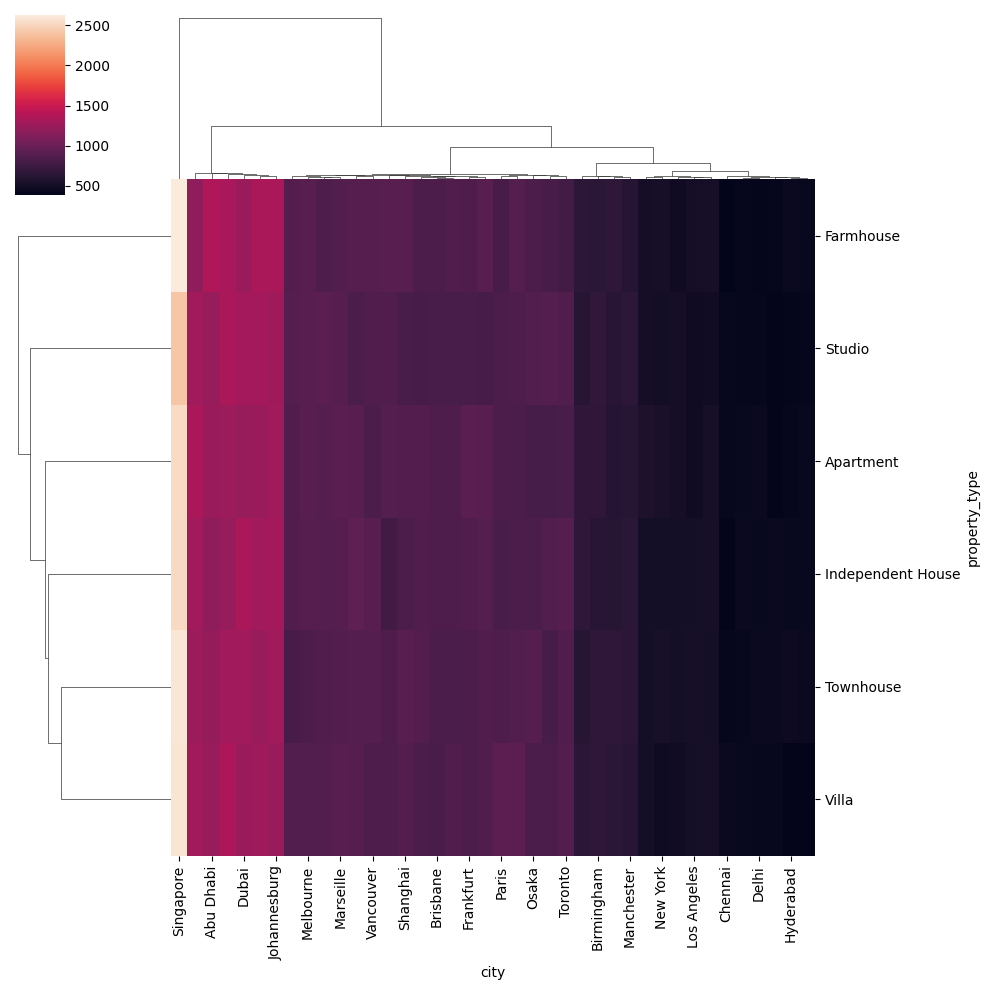

In [28]:
sns.clustermap(pd.crosstab(df["property_type"],df["city"]))

C:\Users\HAMZA\AppData\Local\Temp\ipykernel_2932\3769897815.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'],kde=True)


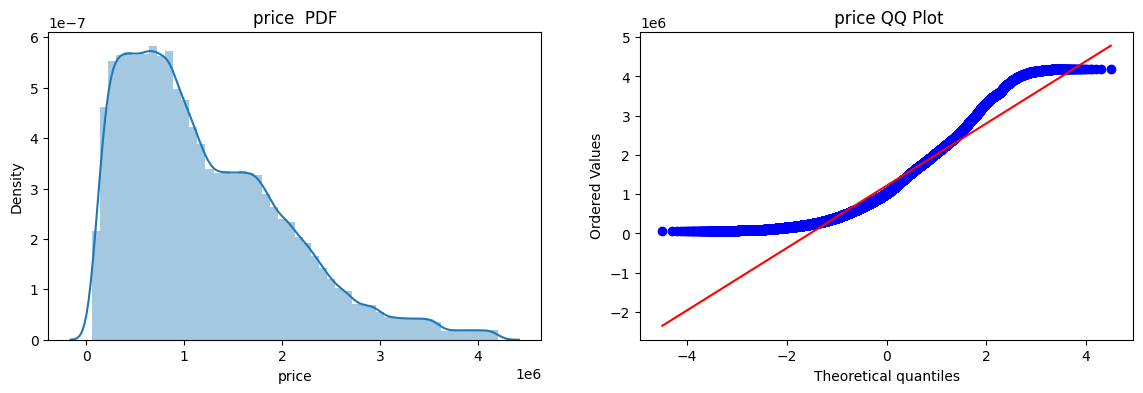

In [29]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(df['price'],kde=True)
plt.title('price  PDF')

plt.subplot(122)
stats.probplot(df['price'], dist="norm", plot=plt)
plt.title(' price QQ Plot')

plt.show()

C:\Users\HAMZA\AppData\Local\Temp\ipykernel_2932\3845746709.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['rooms'],kde=True)


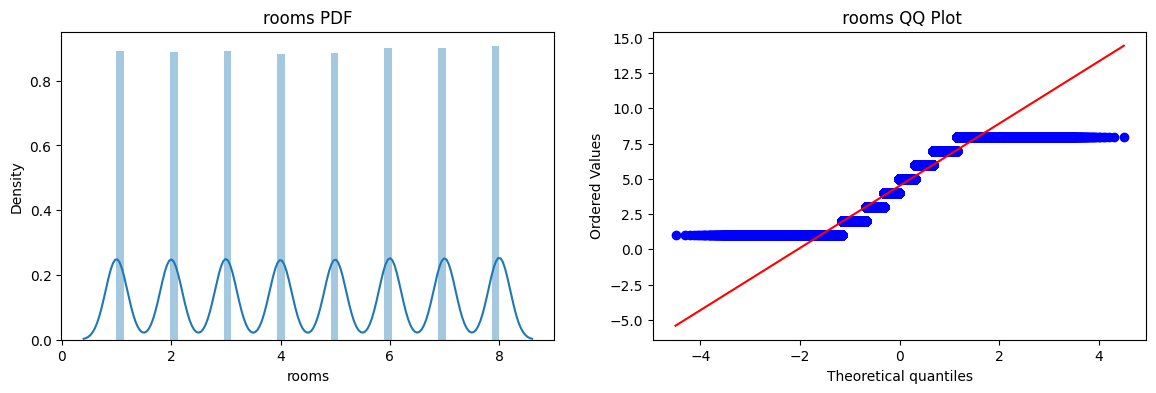

In [30]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(df['rooms'],kde=True)
plt.title('rooms PDF')

plt.subplot(122)
stats.probplot(df['rooms'], dist="norm", plot=plt)
plt.title(' rooms QQ Plot')

plt.show()

C:\Users\HAMZA\AppData\Local\Temp\ipykernel_2932\4123260169.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathrooms'],kde=True)


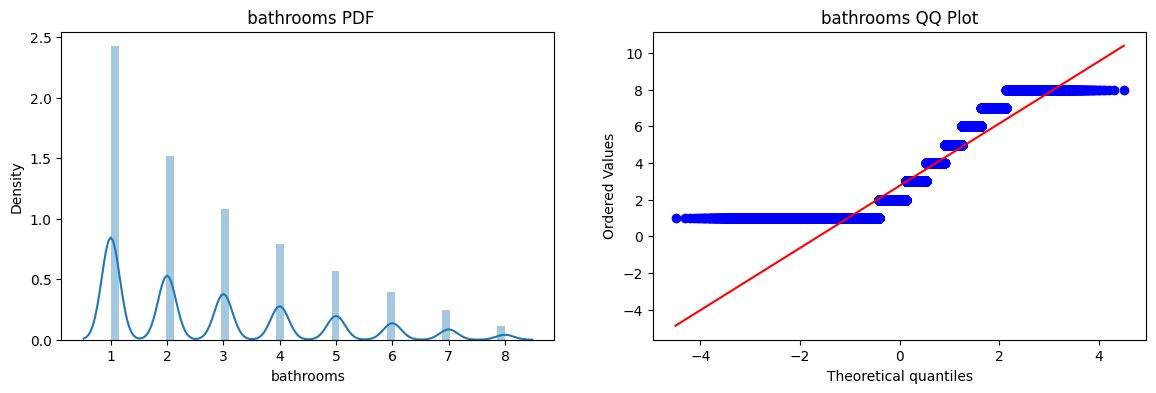

In [31]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(df['bathrooms'],kde=True)
plt.title(' bathrooms PDF')

plt.subplot(122)
stats.probplot(df['bathrooms'], dist="norm", plot=plt)
plt.title('bathrooms QQ Plot')

plt.show()

C:\Users\HAMZA\AppData\Local\Temp\ipykernel_2932\2568691259.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['property_size_sqft'],kde=True)


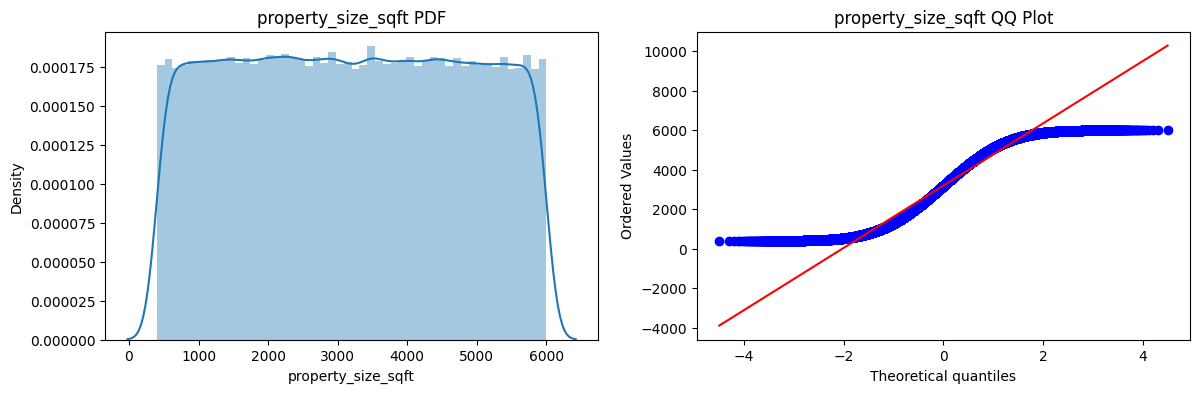

In [32]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(df['property_size_sqft'],kde=True)
plt.title('property_size_sqft PDF')

plt.subplot(122)
stats.probplot(df['property_size_sqft'], dist="norm", plot=plt)
plt.title('property_size_sqft QQ Plot')

plt.show()

C:\Users\HAMZA\AppData\Local\Temp\ipykernel_2932\1289788826.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['satisfaction_score'],kde=True)


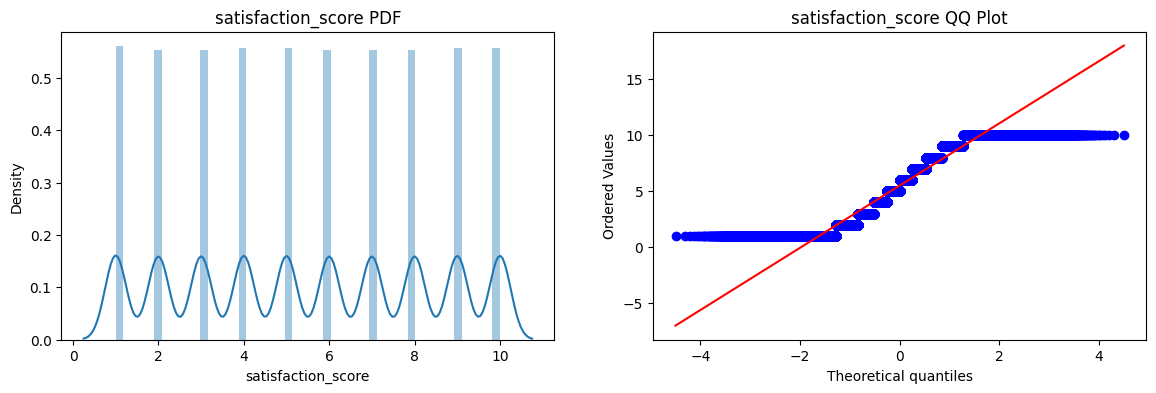

In [33]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(df['satisfaction_score'],kde=True)
plt.title('satisfaction_score PDF')

plt.subplot(122)
stats.probplot(df['satisfaction_score'], dist="norm", plot=plt)
plt.title('satisfaction_score QQ Plot')

plt.show()

# **test_train_split**

In [34]:
X=df.drop('decision',axis=1)
y=df['decision']

In [35]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# **Column Transformer**

In [36]:
preprocessor = ColumnTransformer(transformers=[
  ('OneHot',OneHotEncoder(drop='first', sparse_output=False),['property_type','furnishing_status','city','country']),
  ('Robust', RobustScaler(), ['property_size_sqft','price']),
  ('Standard', StandardScaler(), ['rooms','bathrooms','emi_to_income_ratio'])
],remainder='passthrough')

# **Applying Algorthim**

In [37]:
# RandomForestClassifier
pipeline_rf = Pipeline([
    ('prepro', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# **Fit **

In [38]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

pipeline_rf.fit(X_train, y_train_encoded)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prepro', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHot', ...), ('Robust', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [39]:
rf_acc = pipeline_rf.score(X_test, y_test_encoded)

# **Accuracy score**

In [40]:
accuracy = pipeline_rf.score(X_test, y_test_encoded)
print(f"Random Forest Accuracy:     {accuracy:.4f}")

Random Forest Accuracy:     0.8710


# **Confusion Matrix**

In [41]:
# Use your actual test data and model predictions from the fitted Random Forest pipeline
y_pred = pipeline_rf.predict(X_test)

# Generate the report using your real encoded test labels
print(classification_report(y_test_encoded, y_pred, target_names=[str(c) for c in le.classes_]))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91     30786
           1       0.68      0.85      0.75      9214

    accuracy                           0.87     40000
   macro avg       0.81      0.86      0.83     40000
weighted avg       0.89      0.87      0.88     40000



# **Import Pickle**

In [42]:
import pickle
pickle.dump(pipeline_rf,open('pipe.pkl','wb'))